nmrglue: 0.11
numpy: 2.4.6
scipy: 1.17.1
matplotlib: 3.11.1
pandas: 3.0.5

Peak Fitting Results:

Peak 1 (Position: 335.07 ± 0.19):
  Amplitude: 0.060 ± 0.001
  Width (FWHM): 47.42 ± 0.54 ppm
  Width (FWHM): 3215.22 ± 36.93 Hz
  Carrier Frequency: 67.8041542700043 MHz
  Eta: 0.00 ± 0.06
  Offset: 0.0020 ± 0.0006
  Gaussian Area: 3.04 ± 0.19
  Lorentzian Area: 0.00 ± 0.27
  Total Area: 3.04 ± 0.33

Peak 2 (Position: 431.23 ± 0.19):
  Amplitude: 0.225 ± 0.004
  Width (FWHM): 57.32 ± 0.60 ppm
  Width (FWHM): 3886.81 ± 40.82 Hz
  Carrier Frequency: 67.8041542700043 MHz
  Eta: 0.48 ± 0.02
  Offset: 0.0020 ± 0.0006
  Gaussian Area: 7.08 ± 0.34
  Lorentzian Area: 9.80 ± 0.50
  Total Area: 16.88 ± 0.61

Peak 3 (Position: 497.39 ± 0.25):
  Amplitude: 0.135 ± 0.017
  Width (FWHM): 38.42 ± 1.90 ppm
  Width (FWHM): 2604.81 ± 129.15 Hz
  Carrier Frequency: 67.8041542700043 MHz
  Eta: 0.35 ± 0.08
  Offset: 0.0020 ± 0.0006
  Gaussian Area: 3.62 ± 0.67
  Lorentzian Area: 2.83 ± 0.78
  Total Area: 6.44

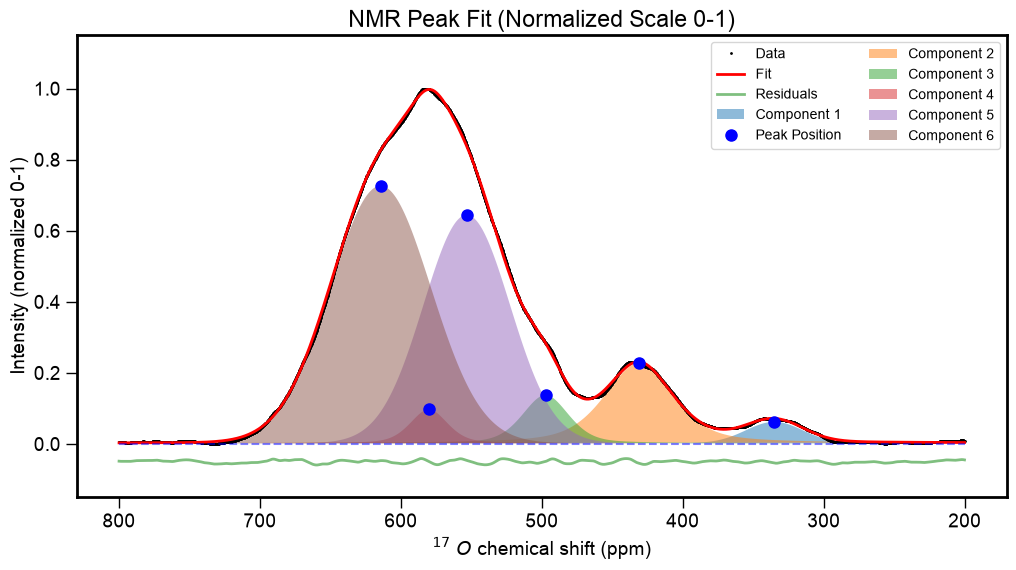

In [1]:
import sys
import matplotlib.pyplot as plt
sys.path.append("../../src")
from nmrlineshapeanalyser.core import NMRProcessor

#create NMRProcessor object

processor = NMRProcessor()

#Load filepath
filepath = r"../../data/six_peaks/5/pdata/1/"


# Load the data

processor.load_data(filepath)

#Select the region of interest

x_data, y_data = processor.select_region(200, 800)

#Normalize the data and return normalised y_axis and the corresponding x_axis

x_data, y_normalized, y_amp, y_ground = processor.normalize_data(x_data, y_data)

#define initial parameters for the fitting
#this example is for a single peak
#format of the parameters is [x0, amplitude, width, eta, offset]
# x0 (position), amplitude, width, eta (mixing parameter), offset
#x0 has to be close to the peak position
#offset is shared across all peaks and must be in the normalized 0-1 scale
initial_params = [
                  334, 0.12, 40.51, 0.89, 0.0, 
                  430, 0.12, 40.51, 0.89, 0.0,
                  497, 0.219, 55.43, 0.52, 0.0,
                  562, 0.12, 40.51, 0.89, 0.0,
                  581, 0.219, 55.43, 0.52, 0.0,
                  623, 0.12, 40.51, 0.89, 0.0
                  ]

number_of_peaks = 6
# fixed_x0 controls whether peak positions should be fixed during fitting
# False means position can vary, True means position is fixed
fixed_x0 = [False]*number_of_peaks

fixed_amp = [False]*number_of_peaks

fixed_width = [False]*number_of_peaks

# fixed_eta controls whether each peak's Gaussian/Lorentzian mixing parameter is fixed
# False means eta is fitted freely (default), True fixes it at its initial_params value
fixed_eta = [False]*number_of_peaks

#FIt the data
popt, metrics, fitted = processor.fit_peaks(x_data, y_normalized, initial_params, fixed_x0, fixed_amp, fixed_width, fixed_eta)

#popt is the optimized parameters
#metrics is the metrics of the fitting
#fitted is the fitted curve data

#Plot and examine the results of the fitting
fig, axes, components = processor.plot_results(x_data, y_normalized, fitted, popt)

#Save the figure as an png file and the results as a csv file
processor.save_results(filepath, x_data, y_normalized, fitted, metrics, popt, components)